In [1]:
import numpy as np
import pickle
import matplotlib.pyplot as plt


import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

from g2p_en import G2p
import re
import torch.nn.utils as utils

import math

import pickle
import Levenshtein
import os

from IPython.display import Audio
import soundfile as sf

In [ ]:
"""
Open and check the data (DATA ALS). 
The data is presented as pickle files. 

DATA.pkl has emg recordings from 597 sentences. Each EMG recording is of the shape (31, T), where 31 is the number
of sensor nodes and T is the number of time steps. EMG data is sampled at 5000 Hertz.

textLABELS.pkl has 597 text labels corresponding to each entry in DATA.pkl

HuBERTLABELS.pkl has 597 HuBERT units corresponding to each entry in DATA.pkl
These HuBERT units can be fed to the Tacotron vocoder to create audio corresponding to 
each entry in DATA.pkl
"""

In [4]:
DATA = pickle.load(open("/mnt/dataDrive/emg2Audio/cleanData/ALS_DATA/DATA.pkl", "rb"))
unitLABELS = np.load("/mnt/dataDrive/emg2Audio/cleanData/ALS_DATA/HuBERTLABELS.npy", allow_pickle = True)
textLABELS = pickle.load(open("/mnt/dataDrive/emg2Audio/cleanData/ALS_DATA/textLABELS.pkl", "rb"))

In [20]:
print("Number of EMG recordings in ALS data:  ", len(DATA))
print("Shape of a EMG recording: ", DATA[0].shape)
print(" ")
print("Number of sentences: ", len(textLABELS))

Number of EMG recordings in ALS data:   597
Shape of a EMG recording:  (31, 30044)
 
Number of sentences:  597


In [6]:
"""
z-normalize the data along time-dimension for each entry.
"""

normDATA = []
for i in range(len(DATA)):
    Mean = np.mean(DATA[i], axis = -1)
    Std = np.std(DATA[i], axis = -1)
    normDATA.append((DATA[i] - Mean[..., np.newaxis])/Std[..., np.newaxis])

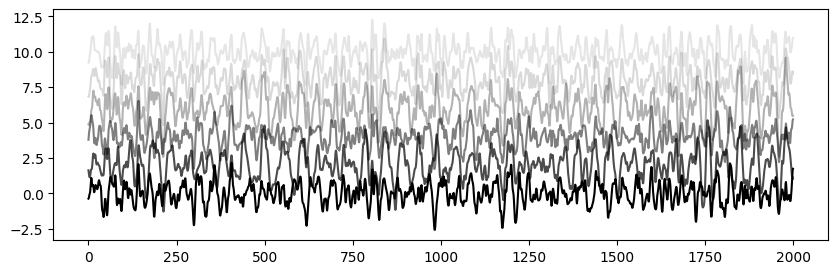

In [19]:
"""View a few EMG data segments."""

plt.figure(figsize = (10, 3))
plt.plot(normDATA[1][0, 500:2500], color = 'black')
plt.plot(normDATA[1][1, 500:2500] + 2, color = 'black', alpha = 0.7)
plt.plot(normDATA[1][2, 500:2500] + 4, color = 'black', alpha = 0.5)
plt.plot(normDATA[1][3, 500:2500] + 6, color = 'black', alpha = 0.3)
plt.plot(normDATA[1][4, 500:2500] + 8, color = 'black', alpha = 0.15)
plt.plot(normDATA[1][5, 500:2500] + 10, color = 'black', alpha = 0.1)
plt.show()

In [10]:
def splitBYindices(data, trainIdx, valIdx, testIdx):
   
    dataList = list(data)
    train = [dataList[i] for i in trainIdx]
    val   = [dataList[i] for i in valIdx]
    test  = [dataList[i] for i in testIdx]
    return train, val, test


N = len(normDATA)         
testIdx = np.array(np.load("/mnt/dataDrive/emg2Audio/cleanData/ALS_DATA/dataSplit.npy"), dtype = int)

mask = np.ones(N, dtype = bool)
mask[testIdx] = False

remainingIdx = np.nonzero(mask)[0]      

nTrain = 500
trainIdx = remainingIdx[:nTrain]
valIdx   = remainingIdx[nTrain:]

print(len(trainIdx), len(valIdx), len(testIdx))

500 37 60


In [12]:
textTrain, textVal, textTest = splitBYindices(textLABELS, trainIdx, valIdx, testIdx)
arrangedTextLabels = textTrain + textVal + textTest

In [13]:
"""
Read the ground truth labels. 500 sentences are used for training, 
37 for validation, and the remaining 60 for test.
"""

for l in arrangedTextLabels:
    print(l)

the window feels warm right now
my wrist is settling gently
the air feels tense now
my breathing feels tense again
please adjust my shoulders carefully now
the pillow is loosening slightly
the mattress feels strained today
my breathing feels relaxed now
the wheelchair feels stiff again
my ankle feels warm again
the noise level feels overwhelming
the curtain feels warm now
the lamp feels cold again
the lighting is improving now
my neck feels tender today
my chest feels weak today
the suction line feels tender today
the pillow is settling well
i feel relieved after stretching
the headrest feels weaker tonight
the window is improving slowly
my shoulder feels tight again
my back feels tender right now
the curtain feels weak today
the footrest is stiff right now
please adjust the suction tubing
my back feels softer tonight
the curtain feels tight today
i feel safe when you guide me
my back feels swollen again
my throat feels warmer now
the curtain feels warm again
the monitor feels tense to

In [15]:
"""
Confirm there is no data leakage.

Of the 60 sentences, there is 1 sentence which is same as in train and validation set. 
This occurred due to manual oversight during data curation. However, it is a very tiny fraction.
"""

count = 0
for i in range(60):
    if arrangedTextLabels[537 + i] in arrangedTextLabels[:537]:
        count += 1

print(count)

1


In [16]:
import sys, os
sys.path.insert(0, "/home/k2/src/textlesslib")  
import textless
print("textless loaded from:", textless.__file__)

import os, re, pathlib, torch, torchaudio
from textless.vocoders.tacotron2.vocoder import TacotronVocoder

device = "cuda" if torch.cuda.is_available() else "cpu"
vocoder = TacotronVocoder.by_name("hubert-base-ls960", "kmeans", 100).to(device)
srOut = vocoder.output_sample_rate
print("vocoder SR:", srOut, "| device:", device)

textless loaded from: /home/k2/src/textlesslib/textless/__init__.py


/home/k2/src/textlesslib/textless/vocoders/tacotron2/vocoder.py:118: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt_dict = torch.load(tacotron_model_path, map_location=t

vocoder SR: 22050 | device: cuda


In [17]:
"""Listen to corresponding audio reconstructed from HuBERT units.
Note that this audio is generated by gTTS.
This audio is not synchronized to user EMG."""
units = torch.tensor(unitLABELS[0], dtype = torch.long, device = device)
wav = vocoder(units) 
Audio(wav.cpu().numpy(), rate = 22050)

/home/k2/src/textlesslib/textless/vocoders/tacotron2/glow.py:269: UserWarning: The torch.cuda.*DtypeTensor constructors are no longer recommended. It's best to use methods such as torch.tensor(data, dtype=*, device='cuda') to create tensors. (Triggered internally at ../torch/csrc/tensor/python_tensor.cpp:78.)
  audio = torch.cuda.FloatTensor(spect.size(0),
/home/k2/src/textlesslib/textless/vocoders/tacotron2/audio_processing.py:82: FutureWarning: Pass size=1024 as keyword args. From version 0.10 passing these as positional arguments will result in an error
  win_sq = librosa_util.pad_center(win_sq, n_fft)


In [ ]:
"""
Duration of the whole data.
"""

timeDuration = 0
for i in range(len(DATA)):
    timeDuration += DATA[i].shape[1]/5000

print("Time duration (in minutes) of the ALS-vocab data is: ", timeDuration/60, "(approximately ", timeDuration/(60 * 60), " hours).")

Time duration (in minutes) of the large-vocab data is:  50.93879666666667 (approximately  0.8489799444444445  hours).
